In [1]:
import sys
from functools import partial
from pathlib import Path

import numpy as np
import pandas as pd
import yaml
from matplotlib import gridspec
from matplotlib import pyplot as plt
from scipy import special, stats
from scipy.signal import savgol_filter
from scipy.stats import gaussian_kde, norm

# Add parent directory to path so we can import the modules
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import dust_jwst_highz.constants as const
from dust_jwst_highz.model.cosmology import cosmo
from dust_jwst_highz.model.dust import (
    compute_mdust_steps,
    grain_size_dist,
    kappa_lambda,
    optical_depth,
    small_carbonaceous_grain_dist,
    stellar_grain_size_dist,
    transmission_sphere_mixed,
)
from dust_jwst_highz.model.halo import log_halo_mass_function
from dust_jwst_highz.model.ism import density_compression_ratio, lognormal_variance_from_mach, sample_surface_density
from dust_jwst_highz.model.luminosity import compute_l1500_steps, l1500_to_muv_conv
from dust_jwst_highz.model.star_formation import halo_to_stellar_mass, star_formation_history
from dust_jwst_highz.utils import enforce_monotonic
from dust_jwst_highz.visualization import Plot_LF_Data, truncate_colormap

plt.rcdefaults()

In [2]:
# Data Loading
DATA_DIR = Path("../data")

dust_pah = pd.read_csv(DATA_DIR / "dust_PAH.csv", comment="#")
dust_graphite = pd.read_csv(DATA_DIR / "dust_graphite.csv", comment="#")
dust_silicate = pd.read_csv(DATA_DIR / "dust_silicate.csv", comment="#")
wavelengths = dust_graphite["wavelength"].unique()[::-1] * 1e4  # µm → Å

# Q_abs: wavelength and grain-size-dependent absorption efficiency
# Shape should be [len(wavelengths) * (len(a) - 1)], flattened
Qabs = np.loadtxt(DATA_DIR / "Q_abs_Draine_silicates.txt", unpack=True, delimiter=",")

# ======== INPUT DATA ===========
# Load SB99 instantaneous burst tables
time_yr, log_snr_yr = np.loadtxt(DATA_DIR / "snr_inst_Z001.txt", usecols=(0, 1), unpack=True)
time_yr_l1500, l1500_sb99 = np.loadtxt(DATA_DIR / "L1500_inst_Z001.txt", usecols=(0, 1), unpack=True)

# Load Hirashita attenuation curve (convert 1/micron to Angstrom)
inv_micron, Alambda_over_Av_hir = np.loadtxt(DATA_DIR / "Hirashita_dense_01Gyr_AttCurve.txt", unpack=True)
lambda_ang_hir = 1e4 / inv_micron

# Load Draine dust model optical properties
lambda_ang_drn = (
    pd.read_csv(DATA_DIR / "Draine_MWDustRv31_Optical_prop.csv", usecols=[0], comment="#").to_numpy().flatten() * 1e4
)  # Convert to Angstrom
# Load Hirashita data
hir_a, hir_a4n = np.loadtxt(DATA_DIR / "Hirashita_a4n_dense_01Gyr.txt", unpack=True, delimiter=",")
hir_a_cm = hir_a * 1e-4  # convert micron to cm


with open(DATA_DIR / "wd01_mw_gsd_params.yaml") as f:
    WD01_MW_PARAMS = yaml.safe_load(f)


rv = "3.1"
dcase = "A"
bc_idx = 2
bc = bc_idx * 1.0e-5

p = WD01_MW_PARAMS[rv][dcase][bc_idx]

graphite_params = p["graphite"].copy()
graphite_params["at"] *= const.micron
graphite_params["ac"] *= const.micron

silicate_params = p["silicate"].copy()
silicate_params["at"] *= const.micron
silicate_params["ac"] = 0.1 * const.micron  # WD01 adopt a_c,s = 0.1 µm for MW

In [3]:
radius_small = 0.001  # 0.001 micron, smallest in Draine table
radius_big = 0.1585  # 0.3 micron, where Hirashita young dust centred

# Densities
rho_carb = 2.24  # graphite
rho_sil = 3.5  # silicate


radius_graphite = dust_graphite["radius"].unique() * const.micron
radius_silicate = dust_silicate["radius"].unique() * const.micron
# -----------------------------
# 2. Choose two grain sizes
# -----------------------------
a_grid = np.logspace(np.log10(3.5e-8), np.log10(1e-4), 500)
phi_graphite_star = stellar_grain_size_dist(radius_graphite, a0_cm=1e-5, sigma=0.47)  # a0 = 0.1 μm
phi_silicate_star = stellar_grain_size_dist(radius_silicate, a0_cm=1e-5, sigma=0.47)

# convert φ(a) → (1/n_H) dn/da with the same D as MW
factor_grapite = const.mean_mol_weight * const.m_p * const.dust_ratio_mw / ((4.0 * np.pi / 3.0) * rho_carb)
factor_silicate = const.mean_mol_weight * const.m_p * const.dust_ratio_mw / ((4.0 * np.pi / 3.0) * rho_sil)

graphite_dist_star = factor_grapite * phi_graphite_star  # same units as dn_da_C
silicate_dist_star = factor_silicate * phi_silicate_star  # same units as dn_da_Si


radius_graphite = dust_graphite["radius"].unique() * const.micron

graphite_dist = grain_size_dist(
    radius_graphite,
    **graphite_params,
    d_func=partial(small_carbonaceous_grain_dist, bc=bc),
)
kappa_c_abs = kappa_lambda(
    radius_graphite,
    dust_graphite.pivot(index="radius", columns="wavelength", values="Q_abs").values,
    graphite_dist,
)
kappa_c_sca = kappa_lambda(
    radius_graphite,
    dust_graphite.pivot(index="radius", columns="wavelength", values="Q_sca").values,
    graphite_dist,
)


# ---- Silicate ----
radius_silicate = dust_silicate["radius"].unique() * const.micron

silicate_dist = grain_size_dist(
    radius_silicate,
    **silicate_params,
)
kappa_s_abs = kappa_lambda(
    radius_silicate,
    dust_silicate.pivot(index="radius", columns="wavelength", values="Q_abs").values,
    silicate_dist,
)
kappa_s_sca = kappa_lambda(
    radius_silicate,
    dust_silicate.pivot(index="radius", columns="wavelength", values="Q_sca").values,
    silicate_dist,
)

wavelength_c = np.sort(dust_graphite["wavelength"].unique())[::-1]
wavelength_s = np.sort(dust_silicate["wavelength"].unique())[::-1]

# --- Carbonaceous ---
kappa_c_abs_star = kappa_lambda(
    radius_graphite,
    dust_graphite.pivot(index="radius", columns="wavelength", values="Q_abs").values[:, ::-1],
    graphite_dist_star,
)[::-1]
kappa_c_sca_star = kappa_lambda(
    radius_graphite,
    dust_graphite.pivot(index="radius", columns="wavelength", values="Q_sca").values[:, ::-1],
    graphite_dist_star,
)[::-1]

# --- Silicate ---
kappa_s_abs_star = kappa_lambda(
    radius_silicate,
    dust_silicate.pivot(index="radius", columns="wavelength", values="Q_abs").values[:, ::-1],
    silicate_dist_star,
)[::-1]
kappa_s_sca_star = kappa_lambda(
    radius_silicate,
    dust_silicate.pivot(index="radius", columns="wavelength", values="Q_sca").values[:, ::-1],
    silicate_dist_star,
)[::-1]

# put both components on the same λ grid (they *should* match; if not, interp)
lam_um = wavelength_c  # = wavelength_s
# Total stellar mixture
kappa_abs_star_tot = kappa_c_abs_star + kappa_s_abs_star
kappa_sca_star_tot = kappa_c_sca_star + kappa_s_sca_star

kappa_ext_star_tot = kappa_abs_star_tot + kappa_sca_star_tot
omega_star_tot = kappa_sca_star_tot / kappa_ext_star_tot  # albedo

# ---- Total MW mixture (C+Si) ----
kappa_abs_tot = (1.0 / 11.0) * kappa_c_abs + (10.0 / 11.0) * kappa_s_abs
kappa_sca_tot = (1.0 / 11.0) * kappa_c_sca + (10.0 / 11.0) * kappa_s_sca

kappa_ext_tot = kappa_abs_tot + kappa_sca_tot  # true extinction
omega_tot = kappa_sca_tot / kappa_ext_tot  # albedo ω(λ)


In [4]:
# set some general constants used throughout

# lambda_uv = 1500
# kv = 8.55e3 / (1 - 0.674)  # cm^2/g
# kuv = 3.92e4 / (1 - 0.3807)  # cm^2/g  # 1400 angstrom
# kuv_hir = kv * hirashita19_attenuation_curve()(lambda_uv)
# kuv_drn = kv * draine03_dust_model()(lambda_uv)

# == Dust Model Parameters (computed in dust_JWST_z10_GSD.py; in principle other GSD can be tried) ==
kuv_hir = 18559.54915539  # 1500 Angstrom opacity [cm^2/g] for Hirashita+22 stellar dust
kuv_hir_abs = 9679.87080737  # 1500 Angstrom absorption opacity [cm^2/g] for Hirashita+22 stellar dust
kv_hir = kappa_ext_star_tot[wavelengths == 5.623e3][0]  # V-band opacity [cm^2/g] for Hirashita+22 stellar dust
kir_hir = kappa_abs_star_tot[wavelengths == 1.585e6][0]  # 158 micron opacity [cm^2/g] for Hirashita+22 stellar dust

kuv_drn = 68476.44934565  # 1500 Angstrom opacity [cm^2/g] for MW-like dust (Draine 2003)
kuv_drn_abs = 33961.82896294  # 1500 Angstrom absorption opacity [cm^2/g] for MW-like dust (Draine 2003)
kv_drn = kappa_ext_tot[wavelengths == 5.623e3][0]  # V-band opacity [cm^2/g] for MW-like dust (Draine 2003)
kir_drn = kappa_abs_tot[wavelengths == 1.585e6][0]  # 158 micron opacity [cm^2/g] for MW-like dust (Draine 2003)

londa = np.array([
    4217., 3981., 3758., 3548., 3350., 3162., 2985., 2818., 2661., 2512.,
    2371., 2239., 2113., 1995., 1884., 1778., 1679., 1585., 1496., 1413.,
    1334., 1259., 1189., 1122., 1059., 1000., 944., 900.
]) / 1600.0  # adimensional # fmt: skip

# Grain size bins [cm], logarithmic in microns
a = np.array([
    1.000e-03, 1.5849e-03, 2.5119e-03, 3.9811e-03, 6.3096e-03, 1.0000e-02,
    1.5849e-02, 2.5119e-02, 3.9811e-02, 6.3096e-02, 1.0000e-01, 1.5849e-01,
    2.5119e-01, 3.9811e-01, 6.3096e-01, 1.0000e+00
]) * 1e-4  # convert microns to cm # fmt: skip

width = 60
print(f"\n{' κ_tot(V band) results '.center(width, '=')}")
print(f"MW WD01 dust (ext)     : {kv_drn:.3f} cm^2 g^-1")
print(f"Stellar dust model (ext): {kv_hir:.3f} cm^2 g^-1")
print("=" * width + "\n")

print(f"{' κ_abs(158 micron) results (for dust emission) '.center(width, '=')}")
print(f"MW WD01 dust (abs)     : {kir_drn:.3f} cm^2 g^-1")
print(f"Stellar dust model (abs): {kir_hir:.3f} cm^2 g^-1")
print("=" * width + "\n")


================== κ_tot(V band) results ===================
MW WD01 dust (ext)     : 20528.853 cm^2 g^-1
Stellar dust model (ext): 21158.046 cm^2 g^-1

====== κ_abs(158 micron) results (for dust emission) =======
MW WD01 dust (abs)     : 12.786 cm^2 g^-1
Stellar dust model (abs): 8.328 cm^2 g^-1



# 2. A mass model for $z\sim10$ galaxies

# 3. Emission model

## Figure 3


==== κ_abs(1500 Å) results ====
MW WD01 dust (ext)     : 68476.44934565 cm^2 g^-1
Stellar dust model (ext): 18559.54915539 cm^2 g^-1
WD01 dust (abs)     : [33721.33239661] cm^2 g^-1
Stellar dust model (abs): [9679.85934644] cm^2 g^-1



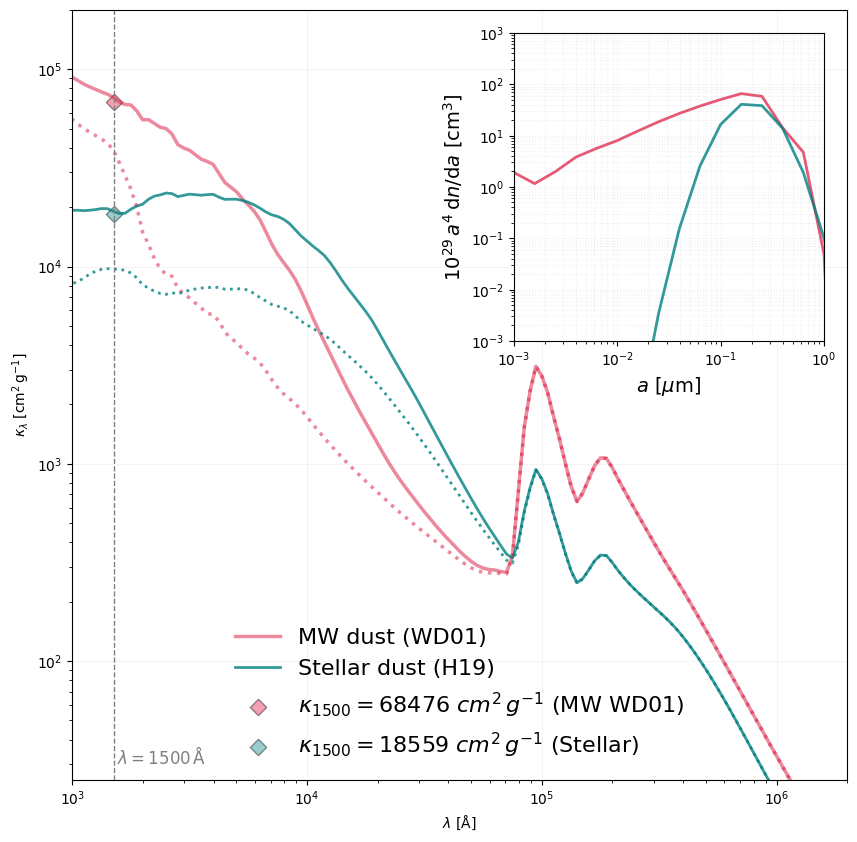

In [5]:
# ==========================================================
# Compare MW WD01 vs stellar dust: κ_λ + a^4 dn/da inset
# ==========================================================

fig, ax = plt.subplots(figsize=(10, 10))

# --- MAIN PANEL: κ_ext(λ) ---
ax.plot(wavelengths, kappa_ext_tot, lw=2.5, alpha=0.5, color="crimson", label="MW dust (WD01)")
ax.plot(wavelengths, kappa_ext_star_tot, lw=2.0, alpha=0.8, color="teal", label="Stellar dust (H19)")
# -- abs
ax.plot(wavelengths, kappa_abs_tot, lw=2.5, alpha=0.5, color="crimson", ls=":")
ax.plot(wavelengths, kappa_abs_star_tot, lw=2.0, alpha=0.8, color="teal", ls=":")


print("\n==== κ_abs(1500 Å) results ====")
print(f"MW WD01 dust (ext)     : {kuv_drn} cm^2 g^-1")
print(f"Stellar dust model (ext): {kuv_hir} cm^2 g^-1")
print(f"WD01 dust (abs)     : {kappa_abs_tot[wavelengths == 1.585e3]} cm^2 g^-1")
print(f"Stellar dust model (abs): {kappa_abs_star_tot[wavelengths == 1.585e3]} cm^2 g^-1")
print("================================\n")

# --- Plot Points at 1500 Å ---
ax.scatter(
    1500,
    kuv_drn,
    color="crimson",
    edgecolor="black",
    s=70,
    marker="D",
    alpha=0.4,
    label=rf"$\kappa_{{1500}}={int(kuv_drn)}$ $cm^2\,g^{{-1}}$ (MW WD01)",
)

ax.scatter(
    1500,
    kuv_hir,
    color="teal",
    edgecolor="black",
    s=70,
    marker="D",
    alpha=0.4,
    label=rf"$\kappa_{{1500}}={int(kuv_hir)}$ $cm^2\,g^{{-1}}$ (Stellar)",
)

# vertical line at 1500 Å
ax.axvline(1500.0, color="gray", linestyle="--", lw=1)


ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim(25, 2e5)
ax.set_xlim(1e3, 2e6)  # 1000 Å – 200 µm

ax.text(1550.0, ax.get_ylim()[0] * 1.2, r"$\lambda=1500\,$Å", fontsize=12, color="gray")


ax.set_xlabel(r"$\lambda\ [\mathrm{\AA}]$")
ax.set_ylabel(r"$\kappa_{\lambda}\ [{\rm cm}^2\,{\rm g}^{-1}]$")
ax.grid(True, alpha=0.2, lw=0.5)
ax.legend(frameon=False, fontsize=16, loc="lower center")

# ==========================================================
# INSET: 1e29 * a^4 dn/da for WD01 vs stellar dust
# ==========================================================
inset_ax = ax.inset_axes([0.57, 0.57, 0.4, 0.4])

# build a common size grid (cm) for total (C+Si)

a_all = np.sort(np.unique(np.concatenate([radius_graphite, radius_silicate])))

# interpolate WD01 dn/da (per H) onto common grid
dn_da_wd = np.interp(a_all, radius_graphite, graphite_dist, left=0.0, right=0.0)
dn_da_wd += np.interp(a_all, radius_silicate, silicate_dist, left=0.0, right=0.0)
# interpolate stellar dn/da onto same grid
dn_da_star = np.interp(a_all, radius_graphite, graphite_dist_star, left=0.0, right=0.0)
dn_da_star += np.interp(a_all, radius_silicate, silicate_dist_star, left=0.0, right=0.0)

# quantity to plot: 1e29 * a^4 dn/da   [cm^3]
y_wd = 1e29 * a_all**4 * dn_da_wd
y_star = 1e29 * a_all**4 * dn_da_star

# convert a to µm for x–axis
inset_ax.loglog(a_all * 1e4, y_wd, color="crimson", alpha=0.7, lw=2, label="MW dust")
inset_ax.loglog(a_all * 1e4, y_star, color="teal", alpha=0.8, lw=2, label="Stellar dust (H19)")

inset_ax.set_xscale("log")
inset_ax.set_yscale("log")
inset_ax.set_xlim(1e-3, 1.0)
# pick a sensible y–range; can tweak after first run
inset_ax.set_ylim(1e-3, 1e3)

inset_ax.set_xlabel(r"$a\ [\mu{\rm m}]$", fontsize=14)
inset_ax.set_ylabel(r"$10^{29}\,a^4\,{\rm d}n/{\rm d}a\ [{\rm cm}^3]$", fontsize=14)
inset_ax.grid(True, which="both", ls=":", alpha=0.2)


# 4. A minimal single-zone, porous ISM

## Figure 6

In [6]:
# --- Helper to get MUV draws for a given Mach using the clumpy LOS logic ---
def get_MUV_clumpy(mach, sigmad_arr, u_seeds_array, n_los, kappa_uv, l_intrinsic):
    """Calculate attenuated UV magnitudes for clumpy ISM model.

    Parameters
    ----------
    mach : float
        Turbulent Mach number
    sigmad_arr : ndarray
        Dust surface density array [g/cm^2]
    u_seeds_array : ndarray
        Quantile seeds for sampling (K_SPINS,)
    n_los : int
        Number of lines-of-sight per spin
    kappa_uv : float
        UV opacity [cm^2/g]
    l_intrinsic : float
        Intrinsic UV luminosity [erg/s/Hz]

    Returns
    -------
    ndarray
        Attenuated UV magnitudes (K_SPINS * n_los,)

    """
    sigma_ln = lognormal_variance_from_mach(mach)
    # seeds from empirical Σ_d distribution
    mu_sigmas = np.quantile(sigmad_arr, u_seeds_array)  # shape (K_SPINS,)

    # LOS quantiles
    u_los = (np.arange(1, n_los + 1) - 0.5) / n_los
    z_los = norm.ppf(u_los)[None, :]  # (1, n_los)

    # Σ_d LOS, then τ, then T, then LUV
    sigmad_los = np.exp(np.log(mu_sigmas)[:, None] + sigma_ln * z_los)  # (K_SPINS, n_los)
    tau_uv_los = kappa_uv * sigmad_los
    transmission_uv_los = transmission_sphere_mixed(tau_uv_los)
    luv_los = l_intrinsic * transmission_uv_los
    luv_draws = luv_los.ravel()

    return -2.5 * np.log10(luv_draws) + 51.60  # MUV_att draws

MUV (intrinsic) --> -22.76907404448489
log Mdust/Msun --> 7.3868619272027285
log Mstar/Msun --> 9.799044994564623


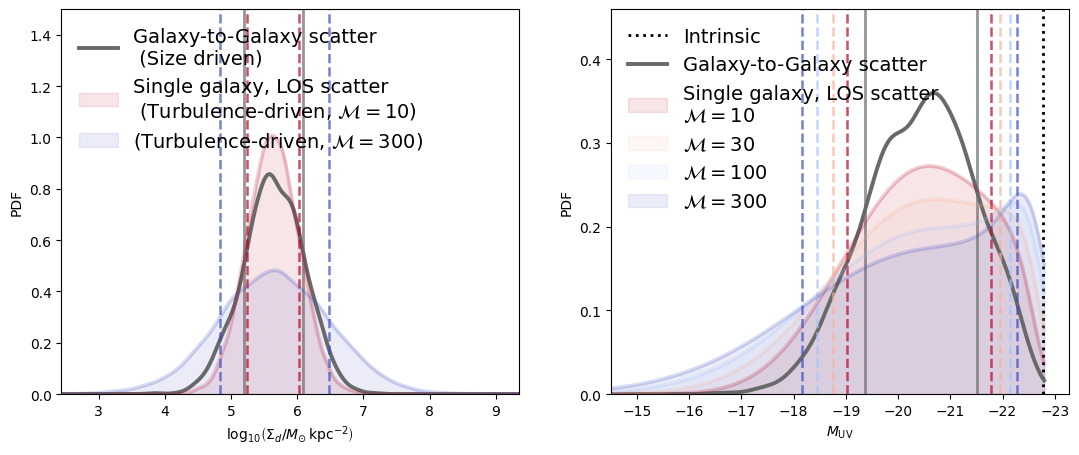

In [8]:
redshift = 7  # 10.0
log_mh = 11.6  # 10.9
fb = cosmo.Ob(redshift) / cosmo.Om(redshift)
epsilon = 0.1
yd = 0.1

col_f = plt.colormaps["gray"]

# ======== CONSTANTS ===========        # Msun in grams
mu = 2.0  # mean molecular weight (not used anymore)
bd = 2.03
kuv = kuv_drn  # cm^2/g
kuv_abs = kuv_drn_abs
kv = kv_drn

np.random.seed(42)

# Stellar mass from halo mass
Mstar_array = halo_to_stellar_mass(10**log_mh, fb, epsilon)

# Build SFH
tstep = 1  # [Myr]
len_sp_dis = 1000
spin_param_distr = np.random.lognormal(mean=np.log(10**-1.5677), sigma=0.5390, size=len_sp_dis)
sfh, log_mst_build, age = star_formation_history(10**log_mh, redshift, tstep, epsilon)

N_SN_arr, Md_arr = compute_mdust_steps(age, tstep, sfh, time_yr, log_snr_yr, yd)

# Compute 1500A luminosity [erg/s/Hz]
L1500_arr = compute_l1500_steps(l1500_sb99, age, tstep, sfh, time_yr_l1500, method="SB99")
Lintr = L1500_arr[-1]  # only last step (final galaxy age) # erg/s/Hz
MUV_intr = l1500_to_muv_conv(Lintr)
L1500_lambda = Lintr * const.c / (1500.0**2 * 1e-8)  # erg/s/Å
print("MUV (intrinsic) -->", MUV_intr)


# ======== BUILD DUST SURFACE DENSITY DISTRIBUTION ===========
### === Setting up shell model with log-normal surface density fluctuations ===

M_dust = Md_arr[-1]
print("log Mdust/Msun -->", np.log10(M_dust))
print("log Mstar/Msun -->", np.log10(Mstar_array))

# Median sigma_d for uniform distribution [g/cm^2]
tauuv_arr = optical_depth(kuv, M_dust, 10**log_mh, spin_param_distr, redshift)
Sigmad_arr = tauuv_arr / kuv  # g/cm^2

# Log-normal draw for sigma_d, width set by Mach number
# Mach=3000  # turbulent Mach number
Sigmad_distr_10 = sample_surface_density(mu_sigma=np.median(Sigmad_arr), mach=10)
Sigmad_distr_300 = sample_surface_density(mu_sigma=np.median(Sigmad_arr), mach=300)

# Build the y-grid (dex) covering your histogram range
R_10 = density_compression_ratio(10)
sigma_ln_sigma_sq_10 = np.log(1 + (R_10 * 10**2) / 4)
sigma_ln_10 = np.sqrt(sigma_ln_sigma_sq_10)
mu_ln_10 = np.log(np.median(Sigmad_arr))
y_vals = np.linspace(-10, -2, 1000)  # dex
x_vals = 10**y_vals

# Transform to the PDF in y = log10 x (units: 1/dex)
pdf_y_10 = np.log(10) * x_vals * stats.lognorm.pdf(x_vals, s=sigma_ln_10, scale=np.exp(mu_ln_10))
# Overlay the correctly transformed PDF (no arbitrary /max)
# plt.plot(y_vals, pdf_y_10, label='PDF Mach=10 (correct in log10-space)', lw=2)


# -----------------------------
# 1) Build MUV distributions for spin-only and for Mach=10,300
# -----------------------------
K_SPINS = 13  # odd, so we include the exact median seed (u=0.5)
W_BLEND = 0.6  # blend between median-seed transmission and mean over seeds
N_LOS = 600  # LOS draws per Mach (distributed across seeds)
albedo = 0.3807
mach_vals = np.array([10, 30, 100, 300])

# exact-median spin seed and symmetric quantiles (data-driven via Sigmad_arr)
u_left = (np.arange(1, (K_SPINS // 2) + 1) - 0.5) / K_SPINS
u_mid = np.array([0.5])
u_right = 1.0 - u_left[::-1]
u_seeds = np.concatenate([u_left, u_mid, u_right])  # length = K_SPINS
mid_idx = K_SPINS // 2


T_1500_uniform = transmission_sphere_mixed(tauuv_arr)  # one value per halo/spin
L1500_uniform = Lintr * T_1500_uniform
MUV_spin = -2.5 * np.log10(L1500_uniform) + 51.60


# ------------------------------------
# Build extra Mach MUV distributions
# ------------------------------------

muv_clumpy = {mach: get_MUV_clumpy(mach, Sigmad_arr, u_seeds, N_LOS, kuv, Lintr) for mach in mach_vals}


cmap = truncate_colormap(plt.cm.coolwarm_r, 0.0, 1.0)
mach_norm = (np.log10(mach_vals) - np.log10(mach_vals.min())) / (np.log10(mach_vals.max()) - np.log10(mach_vals.min()))
mach_colors = [cmap(v) for v in mach_norm]  # [color(M=10), color(30), color(100), color(300)]

# -----------------------------
# 2) Two-panel figure: Σ_d PDFs (left) + MUV PDFs (right)
# -----------------------------
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# ---- LEFT PANEL: Σ_d PDFs in log10-space (KDEs) ----

# conversion factor: g/cm^2 -> Msun/kpc^2
gcm2_to_Msun_kpc2 = (const.kpc**2) / const.M_sun

# convert Σ_d samples to Msun/kpc^2 and take log10
logSig_spin = np.log10(Sigmad_arr * gcm2_to_Msun_kpc2)
logSig_10 = np.log10(Sigmad_distr_10 * gcm2_to_Msun_kpc2)
logSig_300 = np.log10(Sigmad_distr_300 * gcm2_to_Msun_kpc2)

logs_list = [logSig_spin, logSig_10, logSig_300]

# common x-grid in log10(Σ_d / Msun kpc^-2)
x_Sig_min = min(l.min() for l in logs_list)
x_Sig_max = max(l.max() for l in logs_list)
x_Sig = np.linspace(x_Sig_min, x_Sig_max, 400)

# colors & labels (left panel); use Mach colormap for 10 and 300
colors_Sigma = [
    "dimgrey",  # uniform / spin-driven
    mach_colors[0],  # M=10
    mach_colors[-1],  # M=300
]
labels_Sigma = [
    "Galaxy-to-Galaxy scatter\n (Size driven)",
    "Single galaxy, LOS scatter\n (Turbulence-driven, $\\mathcal{M}=10$)",
    "(Turbulence-driven, $\\mathcal{M}=300$)",
]

for i, (logs, col, lab) in enumerate(zip(logs_list, colors_Sigma, labels_Sigma)):
    kde = gaussian_kde(logs)  # KDE in log-space
    pdf = kde(x_Sig)

    if i == 0:
        # Uniform: galaxy-to-galaxy scatter → thick solid line, no fill
        ax[0].plot(x_Sig, pdf, color=col, lw=2.8, label=lab)
        p16, p84 = np.percentile(logs, [16, 84])
        ax[0].axvline(p16, color=col, linestyle="-", lw=2.0, alpha=0.7)
        ax[0].axvline(p84, color=col, linestyle="-", lw=2.0, alpha=0.7)
    else:
        # Turbulence: LOS-to-LOS scatter → shaded + dashed 16–84% lines
        ax[0].fill_between(x_Sig, 0 * x_Sig, pdf, color=col, alpha=0.1, label=lab, zorder=-1000 + i)
        ax[0].plot(x_Sig, pdf, color=col, lw=2.8, alpha=0.2)
        p16, p84 = np.percentile(logs, [16, 84])
        ax[0].axvline(p16, color=col, linestyle="--", lw=1.8, alpha=0.7)
        ax[0].axvline(p84, color=col, linestyle="--", lw=1.8, alpha=0.7)

ax[0].set_xlabel(r"$\log_{10}\!\left(\Sigma_{d}/M_{\odot}\,\mathrm{kpc}^{-2}\right)$")
ax[0].set_ylabel(r"PDF")
ax[0].set_xlim(x_Sig_min, x_Sig_max)
ax[0].set_ylim(0, 1.5)
ax[0].legend(frameon=False, fontsize=14, loc="upper left")
# ---- RIGHT PANEL: MUV_att PDFs (KDEs), same Mach colors ----

# List including new Mach numbers
MUV_list = [MUV_spin] + [muv_clumpy[mach] for mach in mach_vals]

# Colors & labels for right panel:
#   - first: uniform
#   - then: 10, 30, 100, 300 with colormap colors
colors_MUV = ["dimgrey"] + mach_colors
labels_MUV = [
    "Galaxy-to-Galaxy scatter",
    r"Single galaxy, LOS scatter" + "\n" + r"$\mathcal{M}=10$",
    r"$\mathcal{M}=30$",
    r"$\mathcal{M}=100$",
    r"$\mathcal{M}=300$",
]

# Build x-grid for MUV PDFs
all_MUV = np.concatenate(MUV_list)
x_MUV_min, x_MUV_max = all_MUV.min(), all_MUV.max()
x_MUV = np.linspace(x_MUV_min, x_MUV_max, 400)

# add Muv itrinsic line
ax[1].axvline(MUV_intr, color="black", linestyle=":", lw=2.0, label=r"Intrinsic")

for i, (arr, col, lab) in enumerate(zip(MUV_list, colors_MUV, labels_MUV)):
    kde = gaussian_kde(arr)
    pdf = kde(x_MUV)

    if i == 0:
        # Uniform: galaxy-to-galaxy scatter (solid, no fill)
        ax[1].plot(x_MUV, pdf, color=col, lw=2.8, label=lab)
        p16, p84 = np.percentile(arr, [16, 84])
        ax[1].axvline(p16, color=col, linestyle="-", lw=2.0, alpha=0.7)
        ax[1].axvline(p84, color=col, linestyle="-", lw=2.0, alpha=0.7)
    else:
        # Turbulence: LOS-to-LOS scatter → *shaded only* + dashed percentiles
        ax[1].fill_between(x_MUV, 0 * x_MUV, pdf, color=col, alpha=0.1, label=lab)
        ax[1].plot(x_MUV, pdf, color=col, lw=2.8, alpha=0.2)
        p16, p84 = np.percentile(arr, [16, 84])
        ax[1].axvline(p16, color=col, linestyle="--", lw=1.8, alpha=0.7)
        ax[1].axvline(p84, color=col, linestyle="--", lw=1.8, alpha=0.7)


ax[1].set_xlabel(r"$M_{\rm UV}$")
ax[1].set_ylabel(r"PDF")
ax[1].set_ylim(0, 0.46)
ax[1].set_xlim(-14.5, MUV_intr - 0.5)  # keeps brighter magnitudes on the left
ax[1].legend(frameon=False, fontsize=14, loc="upper left")


# 5. Ultraviolet and infrared luminosity functions at $z=7-14$

## Figures 7-10

In [ ]:
redshift = 14
### Fixing tstep for SFH, NB: deve essere breve abbastanza affinche' SN rate interpolato bene, 1-2 Myr vanno bene
tstep = 1  # in [Myr] units
metall = 0.001 / const.Z_sun
log_mh_array = np.linspace(8, 13, 70)

# ---- setup shared stuff ----
Mh_grid = 10**log_mh_array
dndlogM = log_halo_mass_function(log_mh_array, redshift)  # [Mpc^-3 dex^-1]

###Fixing the dust model
kUV = kuv_drn  # kUV_drn  # choose dust opacity model here
kUV_abs = kuv_drn_abs
kv = kv_drn




epsilon =  0.05


epsilon =  0.1


epsilon =  0.2


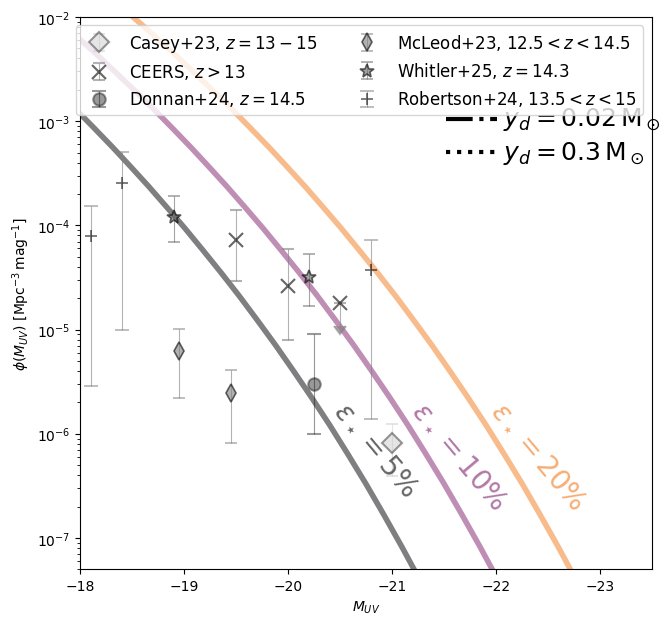

In [9]:
costum_colormap = truncate_colormap(plt.colormaps["inferno"], 0.0, 0.7)

# ------------------------------------------------------------------------------------------
############# Loop in epsilon and yd: compute fract. of optically thick galaxies in the V-band
# ------------------------------------------------------------------------------------------
arr_e = np.array([0.05, 0.10, 0.20])  # [0.2])#0.05, 0.1, 0.6])
arr_yd = np.array([0.02, 0.3])  # , 0.3])
colors = np.array([costum_colormap(0), costum_colormap(0.5), costum_colormap(1.0)])
# if i only run one
# colors=np.array([costum_colormap(0.5), costum_colormap(0.5), costum_colormap(0.5)])


# ============================================
# Clumpy ISM LFs: UV + IR with Σ_d PDF and T_1500_sphere_im
# Two-panel (UV, IR) only when redshift == 7; otherwise UV-only
# NB: Lachlan Method
# ============================================

# ---- knobs ----
K_SPINS = 21  # used only to estimate geometry-induced Σ_d scatter
Mach = 30  # clumpy ISM width (lognormal σ for Σ_d from turbulence)
albedo = 0.3807
K_U = 24  # Gauss–Legendre nodes for Σ_d integral (IR)

# ---- shared stuff ----
Mh_grid = 10**log_mh_array
dndlogM = log_halo_mass_function(log_mh_array, redshift)  # [Mpc^-3 dex^-1]

# spin distribution (for geometry scatter)
mu_ln_spin, sig_ln_spin = np.log(10**-1.5677), 0.5390
u_left = (np.arange(1, (K_SPINS // 2) + 1) - 0.5) / K_SPINS
u_mid = np.array([0.5])
u_right = 1.0 - u_left[::-1]
u = np.concatenate([u_left, u_mid, u_right])  # length = K_SPINS
z_spin = norm.ppf(u)
spin_quant = np.exp(mu_ln_spin + sig_ln_spin * z_spin)  # (K_SPINS,)
mid_idx = K_SPINS // 2


sigma_turb = lognormal_variance_from_mach(Mach)

# Gauss–Legendre nodes for Σ_d integral (in z-space)
xu, wu = np.polynomial.legendre.leggauss(K_U)
u_nodes = np.clip(0.5 * (xu + 1.0), 1e-12, 1 - 1e-12)
w_nodes = 0.5 * wu
z_nodes = norm.ppf(u_nodes)

# --- invert T_1500_sphere_im: precompute τ(T) lookup once ---
tau_max_lookup = 20.0
N_tau = 4000
tau_grid = np.linspace(0.0, tau_max_lookup, N_tau)
T_grid = transmission_sphere_mixed(tau_grid)  # T(τ) for UV

# make T increasing for interpolation τ(T)
T_rev = T_grid[::-1]
tau_rev = tau_grid[::-1]


def tau_of_T(T_target):
    """Invert T_1500_sphere_im(τ) ≈ T_target by interpolation.
    T_target in (0, 1]; vectorized.
    """
    T_target = np.asarray(T_target)
    # clip into the range of precomputed T
    T_clipped = np.clip(T_target, T_rev[0], T_rev[-1])
    return np.interp(T_clipped, T_rev, tau_rev)


# helpers
def _nz(x):
    return np.where(np.abs(x) < 1e-6, np.sign(x) * 1e-6, x)


def _lf_from_curve_sg(x_of_mh, window=9, poly=2):
    # choose an odd window: 7/9/11 depending on len(log_mh_array)
    win = max(7, min(window, len(log_mh_array) - (1 - len(log_mh_array) % 2)))
    dx_dlogMh = savgol_filter(x_of_mh, win, poly, deriv=1, delta=np.mean(np.diff(log_mh_array)), mode="interp")
    dx_dlogMh = _nz(dx_dlogMh)
    return dndlogM / np.abs(dx_dlogMh)


# ============================================
# Figure setup: IR panel only if z=7
# ============================================
if redshift == 7:
    gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1])
    ax_uv = plt.subplot(gs[0])
    ax_ir = plt.subplot(gs[1])
    show_IR = True
else:
    fig, ax_uv = plt.subplots(figsize=(6.8, 6.4))
    ax_ir = None
    show_IR = False

for e, epsilon in enumerate(arr_e):
    color = colors[e]
    print("\n")
    print("epsilon = ", epsilon)

    # ---------- intrinsic L1500 and Md kernel per Mh (ε-dependent) ----------
    L1500_grid = np.empty_like(log_mh_array, float)
    Md1_grid = np.empty_like(log_mh_array, float)  # Md at yd=1
    for j, Mh in enumerate(Mh_grid):
        SFH, logMst_build, age = star_formation_history(Mh, redshift, tstep, epsilon)
        L1500_grid[j] = compute_l1500_steps(l1500_sb99, age, tstep, SFH, time_yr_l1500)[-1]
        Md1_grid[j] = compute_mdust_steps(age, tstep, SFH, time_yr, log_snr_yr, yd=1.0)[1][-1]

    # Intrinsic UV LF (no dust):
    MUV_intr_per_halo = l1500_to_muv_conv(L1500_grid)  # per halo
    MUV_intr = MUV_intr_per_halo.copy()
    phi_intr = _lf_from_curve_sg(MUV_intr)
    MUV_intr, phi_intr = enforce_monotonic(MUV_intr, phi_intr, direction="decreasing")

    # magnitude grid for analytic UV LF
    Mbright = MUV_intr.min() - 1.0  # slightly brighter
    Mfaint = MUV_intr.max() + 1.0  # slightly fainter
    MUV_grid = np.linspace(Mbright, Mfaint, 250)
    nMh = len(Mh_grid)
    nM = len(MUV_grid)

    for yd in arr_yd:
        ls = ":" if yd == arr_yd[1] else "-."

        # scale dust kernel to this yd
        Md_grid = yd * Md1_grid

        # ---------- geometry-induced Σ_d from spins (per halo) ----------
        tauK_grid = np.empty((nMh, K_SPINS))
        Sigma0 = np.empty(nMh)
        sigma_geom = np.empty(nMh)
        for j, Mh in enumerate(Mh_grid):
            tauK = optical_depth(kUV, Md_grid[j], Mh, spin_quant, redshift)  # (K_SPINS,)
            tauK_grid[j, :] = tauK
            SigmaK = tauK / kUV

            # lognormal fit to Σ_d distribution from geometry
            lnSigmaK = np.log(SigmaK)
            Sigma0[j] = np.exp(np.mean(lnSigmaK))  # geometric mean
            sigma_geom[j] = np.std(lnSigmaK)  # ln-space scatter

        # effective Σ_d scatter: geometry + turbulence (independent)
        sigma_eff = np.sqrt(sigma_geom**2 + sigma_turb**2)

        # ---------- uniform-screen UV LF (no clumpiness; median spin) ----------
        tau_med = tauK_grid[:, mid_idx]  # median over spins
        T_uniform = transmission_sphere_mixed(tau_med)
        MUV_uniform = l1500_to_muv_conv(T_uniform * L1500_grid)
        phi_uniform = _lf_from_curve_sg(MUV_uniform)
        MUV_uniform, phi_uniform = enforce_monotonic(MUV_uniform, phi_uniform, direction="decreasing")

        # show uniform curve in faint dashed for reference
        # ax_uv.plot(MUV_uniform, phi_uniform, lw=0.5, ls=ls,
        #           color=color, alpha=0.4)

        # ---------- CLUMPY UV: use lognormal Σ_d + T_1500_sphere_im ----------
        # f_all[j, i] = fraction of galaxies at Mh_j brighter than MUV_grid[i]
        f_all = np.zeros((nMh, nM))
        dfdM = np.zeros_like(f_all)

        for j in range(nMh):
            M_int_j = MUV_intr_per_halo[j]
            Sigma0_j = Sigma0[j]
            sigma_j = sigma_eff[j]

            if not np.isfinite(Sigma0_j) or Sigma0_j <= 0.0 or sigma_j <= 0.0:
                continue

            # required transmission for each M: T_star = Lobs/Lint
            T_star = 10 ** (-0.4 * (MUV_grid - M_int_j))  # can be >1 (unphysical)
            # physically, T_star > 1 means "need brightening" → f = 0
            valid_T = (T_star > 0.0) & (T_star <= 1.0)

            tau_max = np.zeros_like(MUV_grid)
            if np.any(valid_T):
                tau_max[valid_T] = tau_of_T(T_star[valid_T])

            Sigma_max = tau_max / kUV  # Σ_d,max(M, Mh_j)

            # lognormal CDF: f = P(Σ_d < Σ_max)
            f_Mj = np.zeros_like(MUV_grid)
            positive = Sigma_max > 0.0
            if np.any(positive):
                z_ln = (np.log(Sigma_max[positive]) - np.log(Sigma0_j)) / (np.sqrt(2.0) * sigma_j)
                f_Mj[positive] = 0.5 * (1.0 + special.erf(z_ln))

            f_all[j, :] = f_Mj

            # derivative df/dM for this halo (central finite difference)
            df = np.zeros_like(MUV_grid)
            # central points
            df[1:-1] = (f_Mj[2:] - f_Mj[:-2]) / (MUV_grid[2:] - MUV_grid[:-2])
            # edges
            df[0] = (f_Mj[1] - f_Mj[0]) / (MUV_grid[1] - MUV_grid[0])
            df[-1] = (f_Mj[-1] - f_Mj[-2]) / (MUV_grid[-1] - MUV_grid[-2])
            dfdM[j, :] = df

        # integrate over halo mass to get φ(M)
        phi_clumpy = np.zeros_like(MUV_grid)
        for i in range(nM):
            integrand = dndlogM * dfdM[:, i]
            phi_clumpy[i] = np.trapezoid(integrand, log_mh_array)

        # smooth φ(M) in log-space to reduce numerical wiggles
        logphi = np.log10(np.clip(phi_clumpy, 1e-12, None))
        win_M = max(11, min(41, (len(MUV_grid) // 3) * 2 + 1))  # odd window
        logphi_s = savgol_filter(logphi, win_M, 3, mode="interp")
        phi_clumpy_s = 10**logphi_s

        # enforce monotonic non-decreasing φ(M) as M increases (fainter → higher φ)
        phi_mon = phi_clumpy_s.copy()
        for i in range(1, len(phi_mon)):
            if phi_mon[i] < phi_mon[i - 1]:
                phi_mon[i] = phi_mon[i - 1]
        phi_clumpy_s = phi_mon

        # ---------- IR LF: same Σ_d lognormal + T_1500_sphere_im ----------
        LIR_med = np.empty_like(log_mh_array, float)
        for j, Mh in enumerate(Mh_grid):
            L1500 = L1500_grid[j]
            mu_lnSigma = np.log(Sigma0[j])
            sigma_j = sigma_eff[j]

            x_nodes = np.exp(mu_lnSigma + sigma_j * z_nodes)  # Σ_d quadrature nodes
            T_abs_nodes = transmission_sphere_mixed(kUV_abs * x_nodes)
            A_nodes = 1.0 - T_abs_nodes

            f_abs = np.sum(w_nodes * A_nodes)  # average absorbed fraction
            LIR_med[j] = (L1500 * f_abs * (3e10 / (1500e-8))) / const.L_sun

        logLIR_med = np.log10(LIR_med)
        phi_IR = _lf_from_curve_sg(logLIR_med)
        logLIR_med, phi_IR = enforce_monotonic(logLIR_med, phi_IR, direction="decreasing")

        # ---------- plotting ----------
        # clumpy UV LF
        ax_uv.plot(MUV_grid, phi_clumpy_s, lw=3.0, ls=ls, color=color)

        # IR LF (only if z=7)
        if show_IR:
            ax_ir.plot(logLIR_med, phi_IR, lw=3.0, ls=ls, color=color, alpha=0.95)

    # Intrinsic UV LF (no dust), once per ε
    ax_uv.plot(MUV_intr, phi_intr, lw=4.0, color=color, alpha=0.50)

    # in-line text for clarity, specifying SF efficiency
    idx = int(0.5 * len(MUV_intr))  # 0.63 z=7, 0.53 z=14
    x_eps = MUV_intr[idx]
    y_eps = 1.3 * phi_intr[idx]  # 1.3 for z=14
    ax_uv.text(
        x_eps,
        y_eps,
        rf"$\epsilon_\star={epsilon * 100:.0f}\%$",
        fontsize=20,
        color=colors[e],
        rotation=-50,
        rotation_mode="anchor",
        ha="left",
        va="bottom",
        alpha=0.6,
    )  # -30 for z=7 drn, -50 z14


# ---- Big free-floating labels + short horizontal line segments ----
x0, y0 = 0.74, 0.815  # text anchor, 0.74, 0.915 for z=7, for z=14 0.74, 0.815
line_length = 0.10
ax_uv.plot([x0 - line_length, x0 - 0.01], [y0, y0], transform=ax_uv.transAxes, color="black", lw=3, ls="-.")
ax_uv.text(
    x0,
    y0,
    r"$y_d = 0.02\,\mathrm{M_\odot}$",
    transform=ax_uv.transAxes,
    fontsize=18,
    color="black",
    ha="left",
    va="center",
)
x1, y1 = 0.74, 0.755  ## text anchor, 0.74, 0.865 for z=7, for z=14 0.74, 0.755
ax_uv.plot([x1 - line_length, x1 - 0.01], [y1, y1], transform=ax_uv.transAxes, color="black", lw=3, ls=":")
ax_uv.text(
    x1,
    y1,
    r"$y_d = 0.3\,\mathrm{M_\odot}$",
    transform=ax_uv.transAxes,
    fontsize=18,
    color="black",
    ha="left",
    va="center",
)

# --- cosmetics ---
Plot_LF_Data(redshift, ax=ax_uv)
ax_uv.set_yscale("log")
ax_uv.set_ylabel(r"$\phi(M_{UV})\ [\mathrm{Mpc}^{-3}\,\mathrm{mag}^{-1}]$")
ax_uv.set_xlabel(r"$M_{UV}$")

if redshift == 7:
    ax_uv.set_xlim(-19.0, -24.1)
    ax_uv.set_ylim(0.5e-7, 1e-2)

    # plot vertican lines marking REBELS range
    ax_uv.axvspan(-23, -21.0, color="lightskyblue", alpha=0.1, edgecolor="none", zorder=-1000)
    ax_uv.text(-21.6, 0.8e-7, "REBELS", color="lightskyblue", alpha=0.35)

else:
    ax_uv.set_xlim(-18, -23.5)
    ax_uv.set_ylim(0.5e-7, 1e-2)

ax_uv.legend(fontsize=12, ncols=2, loc="upper right")

if show_IR:
    # REBELS z=7 points, table 1 Barrufet+23
    logLIR_dat = np.array([11.45, 11.75, 12.05])
    log_phi = np.array([-4.3, -4.6, -5.5])
    # max err btween detection and non detection, cause hihgly uncertain
    log_phi_uerr = np.array([0.2, 0.3, 0.4])
    log_phi_lerr = np.array([0.2, 0.3, 0.5])
    phi_data = 10**log_phi
    phi_uerr = 10 ** (log_phi + log_phi_uerr) - phi_data
    phi_lerr = phi_data - 10 ** (log_phi - log_phi_lerr)
    ax_ir.errorbar(
        logLIR_dat,
        phi_data,
        yerr=[phi_lerr, phi_uerr],
        ls="none",
        marker="s",
        ms=10,
        capsize=5,
        alpha=0.7,
        color="darkred",
        label="REBELS\n Barrufet+23, $z=7$",
        mew=1.5,
        mec="black",
        elinewidth=0.8,
    )

    ax_ir.set_yscale("log")
    ax_ir.set_ylabel(r"$\phi(\log_{10} L_{\mathrm{IR}})\ [\mathrm{Mpc}^{-3}\,\mathrm{dex}^{-1}]$")
    ax_ir.set_xlabel(r"$\log_{10}(L_{\mathrm{IR}}/L_{\odot})$")
    ax_ir.set_ylim(1.0e-7, 1e-3)
    ax_ir.set_xlim(10.4, 13.4)
    ax_ir.legend(fontsize=12, ncols=2, loc="upper right")
    plt.subplots_adjust(left=0.07, bottom=0.087, right=0.983, top=0.958, wspace=0.169, hspace=0.2)
else:
    plt.subplots_adjust(left=0.12, bottom=0.087, right=0.96, top=0.95)

plt.show()


Data ADDED!




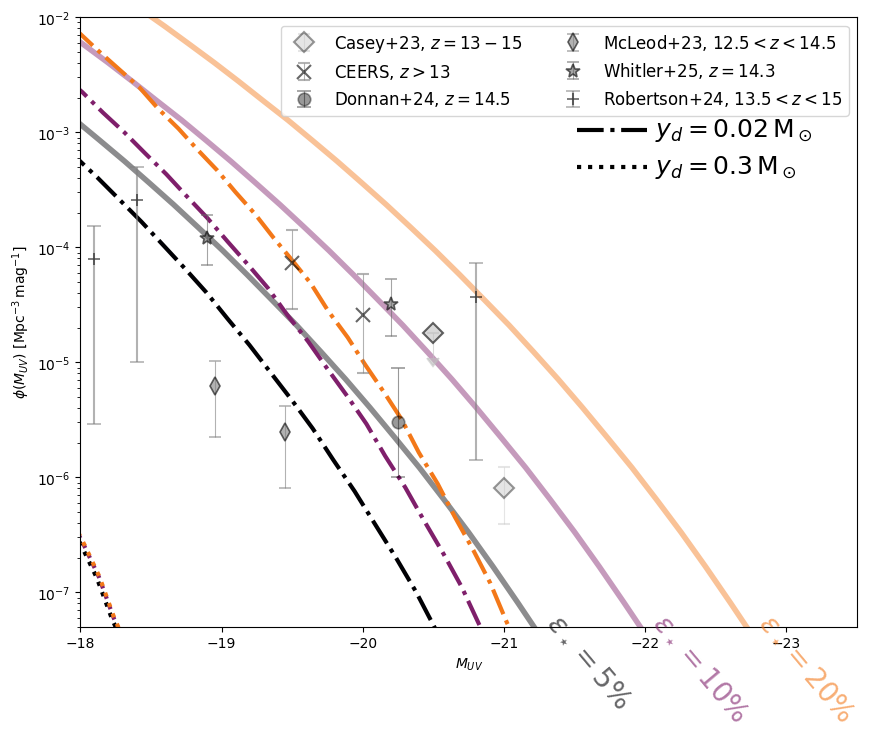

In [ ]:
# -------------------------------------------------------
######### UV LF with SN dust correction (z=redshift)
# -------------------------------------------------------

# ---- knobs for the "in-between" behavior ----
K_SPINS = 7  # small number of stratified spins per mass (5–9 works well)
W_BLEND = 0.6  # 0=median, 1=mean; pick ~0.5–0.7 for "in-between"
log_mh_array = np.linspace(8, 13, 70)

# ---- setup shared stuff ----
Mh_grid = 10**log_mh_array
dndlogM = log_halo_mass_function(log_mh_array, redshift)  # [Mpc^-3 dex^-1]
mu_ln, sig_ln = np.log(10**-1.5677), 0.5390

# fixed stratified quantiles in (0,1)
u = (np.arange(1, K_SPINS + 1) - 0.5) / K_SPINS
z = norm.ppf(u)  # standard-normal quantiles
spin_quant = np.exp(mu_ln + sig_ln * z)  # lognormal quantiles for lambda, shape (K_SPINS,)

fig, ax = plt.subplots(figsize=(9, 7))

for e, epsilon in enumerate(arr_e):
    # cache intrinsic + dust kernel once per (epsilon, Mh)
    Mh_grid = 10**log_mh_array
    L1500_grid = np.empty_like(log_mh_array, float)
    Md1_grid = np.empty_like(log_mh_array, float)  # final Md at yd=1

    for j, Mh in enumerate(Mh_grid):
        SFH, logMst_build, age = star_formation_history(Mh, redshift, tstep, epsilon)
        L1500_grid[j] = compute_l1500_steps(l1500_sb99, age, tstep, SFH, time_yr_l1500)[-1]
        Md1_grid[j] = compute_mdust_steps(age, tstep, SFH, time_yr, log_snr_yr, yd=1.0)[1][-1]

    MUV_intr = l1500_to_muv_conv(L1500_grid)

    for yd in arr_yd:
        ls = ":" if yd == arr_yd[1] else "-."  # if yd == arr_yd[0] else ('--' if yd == arr_yd[1] else '-'))

        # scale dust kernel to this yd
        Md_grid = yd * Md1_grid

        # compute T for each stratified spin; blend mean/median => T_eff
        # loop over Mh (cheap: K_SPINS is small)
        T_eff = np.empty_like(Mh_grid, float)
        for j, Mh in enumerate(Mh_grid):
            # tau for K spins at this Mh
            tauK = optical_depth(kUV, Md_grid[j], Mh, spin_quant, redshift)  # expects vector spins
            TK = transmission_sphere_mixed(tauK)  # shape (K_SPINS,)

            T_med = np.median(TK)
            T_mean = np.mean(TK)
            T_eff[j] = (1.0 - W_BLEND) * T_med + W_BLEND * T_mean

        # attenuated mags using the blended transmission
        MUV_att = l1500_to_muv_conv(T_eff * L1500_grid)

        # ---- Jacobian -> LFs ----
        dMUV_dlogM_att = np.gradient(MUV_att, log_mh_array)
        dMUV_dlogM_intr = np.gradient(MUV_intr, log_mh_array)

        # avoid zeros in derivative
        eps_der = 1e-6
        dMUV_dlogM_att = np.where(np.abs(dMUV_dlogM_att) < eps_der, np.sign(dMUV_dlogM_att) * eps_der, dMUV_dlogM_att)
        dMUV_dlogM_intr = np.where(
            np.abs(dMUV_dlogM_intr) < eps_der, np.sign(dMUV_dlogM_intr) * eps_der, dMUV_dlogM_intr
        )

        phi_att = dndlogM / np.abs(dMUV_dlogM_att)
        phi_intr = dndlogM / np.abs(dMUV_dlogM_intr)

        MUV_att, phi_att = enforce_monotonic(MUV_att, phi_att, direction="decreasing")
        MUV_intr, phi_intr = enforce_monotonic(MUV_intr, phi_intr, direction="decreasing")

        # numpy safety
        phi_att = np.where(np.isfinite(phi_att) & (phi_att > 0), phi_att, np.nan)
        phi_intr = np.where(np.isfinite(phi_intr) & (phi_intr > 0), phi_intr, np.nan)

        ax.plot(
            MUV_att, phi_att, lw=3.0, ls=ls, color=colors[e]
        )  # ,label=fr"ATT: $\epsilon$={epsilon}, $y_d$={yd}", alpha=0.9)#(K={K_SPINS}, w={W_BLEND})

    ax.plot(MUV_intr, phi_intr, lw=4.0, color=colors[e], alpha=0.45)  # label=fr"Intrinsic, $\epsilon$={epsilon}"

    # in line text for clarity, specifying SF efficiency
    idx = int(0.58 * len(MUV_intr))
    x_eps = MUV_intr[idx]
    y_eps = 1.3 * phi_intr[idx]
    ax.text(
        x_eps,
        y_eps,
        rf"$\epsilon_\star={epsilon * 100:.0f}\%$",
        fontsize=20,
        color=colors[e],
        rotation=-50,
        rotation_mode="anchor",
        ha="left",
        va="bottom",
        alpha=0.6,
    )


# ---- Big free-floating labels + short horizontal line segments ----
# y_d = 1e-3  (dash-dot)
x0, y0 = 0.74, 0.815  # text anchor
line_length = 0.10  # fraction of axes width
ax.plot([x0 - line_length, x0 - 0.01], [y0, y0], transform=ax.transAxes, color="black", lw=3, ls="-.")
ax.text(
    x0,
    y0,
    r"$y_d = 0.02\,\mathrm{M_\odot}$",
    transform=ax.transAxes,
    fontsize=18,
    color="black",
    ha="left",
    va="center",
)
# y_d = 0.3 (dashed)
x1, y1 = 0.74, 0.755
ax.plot([x1 - line_length, x1 - 0.01], [y1, y1], transform=ax.transAxes, color="black", lw=3, ls=":")
ax.text(
    x1, y1, r"$y_d = 0.3\,\mathrm{M_\odot}$", transform=ax.transAxes, fontsize=18, color="black", ha="left", va="center"
)


# Data & axes
Plot_LF_Data(redshift, ax=ax)
ax.set_yscale("log")
ax.set_ylabel(r"$\phi(M_{UV})\ [\mathrm{Mpc}^{-3}\,\mathrm{mag}^{-1}]$")
ax.set_xlabel(r"$M_{UV}$")
if redshift == 7:
    # plot vertican lines marking REBELS range
    ax.axvspan(-23, -21.0, color="lightskyblue", alpha=0.1, edgecolor="none", zorder=-1000)
    ax.text(-21.6, 0.8e-7, "REBELS", color="lightskyblue", alpha=0.35)
    ax.set_xlim(-19, -24.1)
    ax.set_ylim(0.5e-7, 1e-2)
else:
    ax.set_xlim(-18, -23.5)  # more negative MUV = brighter; bright end on RIGHT
    ax.set_ylim(0.5e-7, 1e-2)

ax.legend(fontsize=12, ncols=2, loc="upper right")

plt.subplots_adjust(left=0.12, bottom=0.087, right=0.983, top=0.958, wspace=0.2, hspace=0.2)

plt.show()

# 6. Discussions and caveats